# Purpose

Ridge Regression Volatility Model

This notebook trains a Ridge Regression model to predict future 20-day realized volatility.

The goal is to compare a regularized linear model against the baseline model and the regular Linear Regression model. 

Ridge Regression is similar to Linear Regression, but it adds a penalty that helps reduce overly large coefficients. This can make the model more stable when features are highly related to each other.


# Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# ENUM Path

In [2]:
FEATURE_DATA_PATH = Path("../../data/processed/features")
MODELING_PATH = Path("../../data/processed/modeling")
MODEL_OUTPUT_PATH = MODELING_PATH / "ridge_regression"
MODEL_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)


# Load in Feature Data

In [3]:
df = pd.read_csv(
    FEATURE_DATA_PATH / "feature_engineered_dataset.csv",
    parse_dates=["Date"]
)

In [4]:
df.head()

,Date,ticker,adjusted_close,daily_return,risk_free_rate_decimal,vix,treasury_10yr_pct,yield_curve_spread,is_inverted,fed_funds_rate_pct,...,rolling_return_20d,abs_return,squared_return,rolling_abs_return_20d,rolling_squared_return_20d,rolling_volatility_5d,rolling_volatility_20d,moving_avg_20d,price_to_moving_avg_20d,future_volatility_20d
0,2018-01-31,AAPL,39.138020,0.002755,0.0146,13.54,2.72,1.26,0,1.41,...,-0.001378,0.002755,0.000008,0.006855,0.000087,0.011013,0.009462,40.695438,0.961730,0.022707
1,2018-02-01,AAPL,39.219841,0.002091,0.0148,13.47,2.78,1.30,0,1.42,...,-0.001265,0.002091,0.000004,0.006951,0.000087,0.010065,0.009490,40.643427,0.964974,0.022726
2,2018-02-02,AAPL,37.518093,-0.043390,0.0148,17.31,2.84,1.36,0,1.42,...,-0.003667,0.043390,0.001883,0.008888,0.000180,0.019425,0.013250,40.496978,0.926442,0.019948
3,2018-02-05,AAPL,36.580715,-0.024985,0.0151,37.32,2.77,1.26,0,1.42,...,-0.005485,0.024985,0.000624,0.009568,0.000205,0.019936,0.013567,40.280635,0.908146,0.018715
4,2018-02-06,AAPL,38.109501,0.041792,0.0152,29.98,2.79,1.27,0,1.42,...,-0.003210,0.041792,0.001747,0.011472,0.000292,0.032292,0.017207,40.148329,0.949218,0.017050


In [5]:
df.shape

(41370, 30)

# Feature and Target Column Selection

In [6]:
FEATURES_COLS = [
    "return_lag_1",
    "return_lag_5",
    "rolling_return_5d",
    "rolling_return_20d",
    "abs_return",
    "squared_return",
    "rolling_abs_return_20d",
    "rolling_squared_return_20d",
    "rolling_volatility_5d",
    "rolling_volatility_20d",
    "price_to_moving_avg_20d",
    "risk_free_rate_decimal",
    "vix",
    "treasury_10yr_pct",
    "yield_curve_spread",
    "is_inverted",
    "fed_funds_rate_pct",
    "unemployment_rate_pct",
    "recession_flag",
    "cpi_pct_change"
]

TARGET_COLS = "future_volatility_20d"

# Tim-Based Train/Split 

In [7]:
train = df[df["Date"] < "2024-01-01"].copy()
test = df[df["Date"] >= "2024-01-01"].copy()

X_train = train[FEATURES_COLS]
y_train = train[TARGET_COLS]

X_test = test[FEATURES_COLS]
y_test = test[TARGET_COLS]

# Baseline Prediction

In [8]:
baseline_pred = test["rolling_volatility_20d"]

# Train Ridge Regression Model

In [9]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 25)))
])

In [10]:
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+04])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yield

In [11]:
ridge_pred = ridge_model.predict(X_test)

# Check Best Alpha Val

In [12]:
best_alpha = ridge_model.named_steps["ridge"].alpha_

In [13]:
best_alpha

0.46415888336127775

# Evaluation Function

In [14]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Result Table

In [15]:
linear_regression_result = (
    pd.read_csv(MODELING_PATH / "linear_regression" / "metrics.csv")
    .query("model == 'Linear Regression'")
    .iloc[0]
    .to_dict()
)

In [16]:
results = pd.DataFrame([
    evaluate_model("Baseline: rolling_volatility_20d", y_test, baseline_pred),
    linear_regression_result,
    evaluate_model("Ridge Regression", y_test, ridge_pred)
])

In [17]:
results

,model,MAE,RMSE,R2
0,Baseline: rolling_volatility_20d,0.004647,0.007130,0.001510
1,Linear Regression,0.005107,0.007456,-0.091727
2,Ridge Regression,0.005103,0.007452,-0.090511


# Ridge Coefficients

In [18]:
ridge_coefficients = pd.DataFrame({
    "feature": FEATURES_COLS,
    "coefficient": ridge_model.named_steps["ridge"].coef_
}).sort_values("coefficient", ascending=False)

In [19]:
ridge_coefficients

,feature,coefficient
6,rolling_abs_return_20d,0.005344
11,risk_free_rate_decimal,0.003138
9,rolling_volatility_20d,0.002202
13,treasury_10yr_pct,0.001614
18,recession_flag,0.001187
8,rolling_volatility_5d,0.000992
15,is_inverted,0.000623
12,vix,0.000401
4,abs_return,0.000368
3,rolling_return_20d,0.000282


# Create Prediction Output Table

In [20]:
prediction_results = test[
    ["Date", "ticker", "future_volatility_20d", "rolling_volatility_20d"]
].copy()

In [21]:
prediction_results["ridge_prediction"] = ridge_pred
prediction_results["absolute_error"] = (
    prediction_results["future_volatility_20d"]
    - prediction_results["ridge_prediction"]
).abs()

In [22]:
prediction_results.head()

,Date,ticker,future_volatility_20d,rolling_volatility_20d,ridge_prediction,absolute_error
1489,2024-01-02,AAPL,0.013366,0.012075,0.013476,0.000110
1490,2024-01-03,AAPL,0.013582,0.012014,0.012865,0.000717
1491,2024-01-04,AAPL,0.013296,0.011036,0.012335,0.000961
1492,2024-01-05,AAPL,0.013373,0.011021,0.011742,0.001631
1493,2024-01-08,AAPL,0.012426,0.012272,0.013231,0.000805


In [23]:
prediction_results.to_csv(
    MODEL_OUTPUT_PATH / "test_predictions.csv",
    index=False
)

results.to_csv(
    MODEL_OUTPUT_PATH / "metrics.csv",
    index=False
)

print("Saved:", MODEL_OUTPUT_PATH / "test_predictions.csv")
print("Saved:", MODEL_OUTPUT_PATH / "metrics.csv")


Saved: ..\..\data\processed\modeling\ridge_regression\test_predictions.csv
Saved: ..\..\data\processed\modeling\ridge_regression\metrics.csv


# Actual VS Predicted Plot Comparison

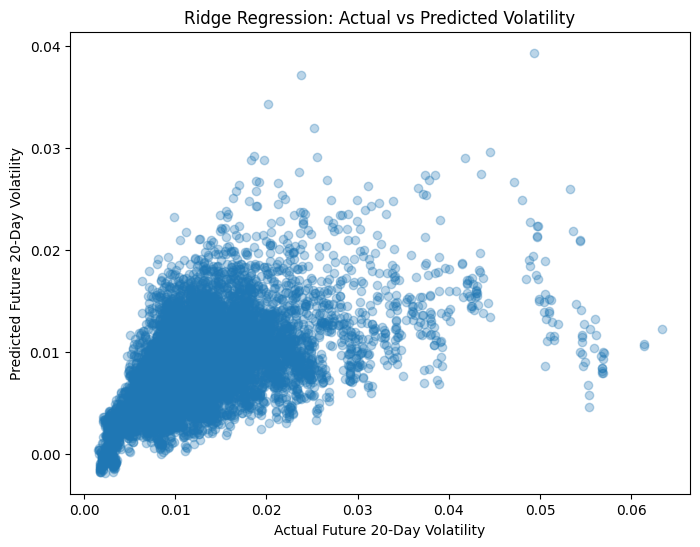

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, ridge_pred, alpha=0.3)

plt.xlabel("Actual Future 20-Day Volatility")
plt.ylabel("Predicted Future 20-Day Volatility")
plt.title("Ridge Regression: Actual vs Predicted Volatility")

plt.show()

# Conclusion

In this notebook, I trained a Ridge Regression model to predict `future_volatility_20d`, which represents the realized volatility over the next 20 trading days for each asset.

Ridge Regression is similar to Linear Regression model, but it adds regularization. This means the model will penalize very large coefficients, which can make the model more stable when features are highly related to each other. This is useful for this project because several of the features are closely connected, especially the rolling volatility, rolling absolute return, and rolling squared return features.

The RidgeCV model selected an alpha value of `10.0`, meaning it applied a moderate amount of regularization. The Ridge Regression model had an MAE of `0.003943`, an RMSE of `0.005984`, and an R2 score of `0.296628`.

Compared to the baseline model, Ridge Regression performed much better. The baseline had an MAE of `0.004647`, an RMSE of `0.007130`, and an R2 score of only `0.001510`. This shows that the engineered features provide more useful information than simply assuming future volatility will equal recent 20-day volatility.

Compared to the regular Linear Regression model, Ridge Regression performed almost exactly the same. Linear Regression had an MAE of `0.003941`, an RMSE of `0.005984`, and an R2 score of `0.296699`. Ridge Regression was only slightly worse, but the difference is extremely small.

So overall, Ridge Regression confirms that a regularized linear model works well for this volatility prediction problem. However, regularization did not really meaningfully improve performance compared to the original Linear Regression model. 

So this suggests that the Linear Regression model was already fairly stable, and the relationship between the selected features and future volatility can be captured well with a simple linear approach. But for the final project, Ridge Regression is still useful as a comparison model because it shows that the strong Linear Regression results were not only due to overly large or unstable coefficients.